### 1. Imports and Load Results

In [ ]:
import json
from pathlib import Path

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------------------------------------------------
# Plot style -- consistent across all figures in this notebook.
# Using a minimal style so plots are readable in both light and dark
# VSCode themes without hard-coding background colours.
# -----------------------------------------------------------------------

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10,
})

COLOUR_FP32    = '#2b7bb9'   # Blue for FP32 model
COLOUR_TERNARY = '#d95f02'   # Orange for ternary model

# -----------------------------------------------------------------------
# Configuration mirrors notebook 00.
# -----------------------------------------------------------------------

TASK_NAMES  = ['fibonacci', 'fizzbuzz', 'parity', 'primes']
EPOCHS      = 300
EVAL_EVERY  = 10
TERNARY_THRESH = 0.05

ROOT_DIR    = Path('..').resolve()
METRICS_DIR = ROOT_DIR / 'metrics'

# -----------------------------------------------------------------------
# Run selection -- set RUN_NAME to a specific folder name to load that
# run, or leave as None to automatically load the most recent run.
# Example: RUN_NAME = 'run_20240101_120000'
# -----------------------------------------------------------------------

RUN_NAME = None

if RUN_NAME is None:
    run_dirs = sorted([d for d in METRICS_DIR.iterdir() if d.is_dir() and d.name.startswith('run_')])
    if not run_dirs:
        raise FileNotFoundError(f'No run folders found in {METRICS_DIR}')
    RUN_DIR = run_dirs[-1]
else:
    RUN_DIR = METRICS_DIR / RUN_NAME

PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------
# Load the JSON metrics file produced by notebook 03.
# -----------------------------------------------------------------------

metrics_path = RUN_DIR / 'training_metrics.json'
with open(metrics_path) as f:
    M = json.load(f)

fp32_m    = M['fp32']
ternary_m = M['ternary']

epochs_range       = list(range(1, len(fp32_m['train_loss']) + 1))
task_acc_epochs    = fp32_m['task_acc_epochs']
ternary_epochs     = ternary_m['ternary_epochs']

# print(f'Metrics loaded   : {metrics_path}')
print(f'Epochs recorded  : {len(epochs_range)}')
print(f'Eval checkpoints : {len(task_acc_epochs)}')

### 2. Loss Curves

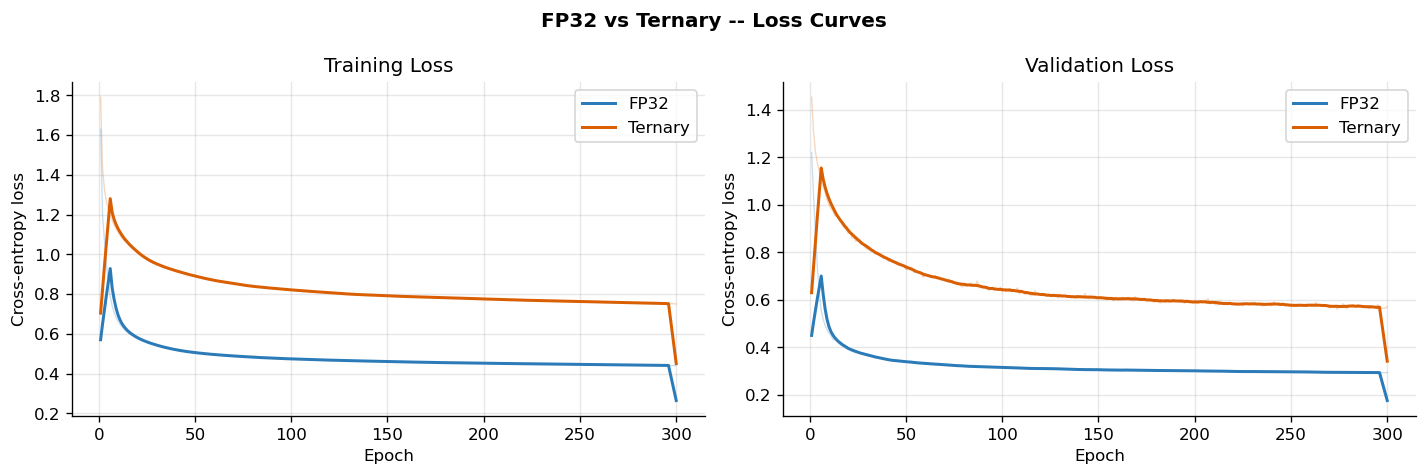

Metric                                     FP32     Ternary
------------------------------------------------------------
Final train loss                         0.4402      0.7504
Final val loss                           0.2937      0.5706
Best val loss (min)                      0.2924      0.5606
Epoch of best val loss                      290         274


In [10]:
# -----------------------------------------------------------------------
# Loss curves for both models on train and validation sets.
# Two panels: training loss (left) and validation loss (right).
# The smoothed line overlays the raw curve to make trends legible when
# the ternary loss is noisy early in training.
# -----------------------------------------------------------------------

def smooth(values, window=10):
    '''
    Simple moving-average smoothing over a list of scalar values.

    Parameters
    ----------
    values : list[float]
    window : int

    Returns
    -------
    numpy.ndarray
        Smoothed values, same length as input.
    '''
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='same')


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, metric_key, title in zip(axes, ['train_loss', 'val_loss'], ['Training Loss', 'Validation Loss']):

    fp32_vals    = fp32_m[metric_key]
    ternary_vals = ternary_m[metric_key]

    # Raw curves at low opacity as context
    ax.plot(epochs_range, fp32_vals,    color=COLOUR_FP32,    alpha=0.25, linewidth=0.8)
    ax.plot(epochs_range, ternary_vals, color=COLOUR_TERNARY, alpha=0.25, linewidth=0.8)

    # Smoothed curves as the primary visual
    ax.plot(epochs_range, smooth(fp32_vals),    color=COLOUR_FP32,    linewidth=1.8, label='FP32')
    ax.plot(epochs_range, smooth(ternary_vals), color=COLOUR_TERNARY, linewidth=1.8, label='Ternary')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend()

fig.suptitle('FP32 vs Ternary -- Loss Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'loss_curves.png', bbox_inches='tight')
plt.show()

# Numeric summary
print(f'{"Metric":<35}  {"FP32":>10}  {"Ternary":>10}')
print('-' * 60)
print(f'{"Final train loss":<35}  {fp32_m["train_loss"][-1]:>10.4f}  {ternary_m["train_loss"][-1]:>10.4f}')
print(f'{"Final val loss":<35}  {fp32_m["val_loss"][-1]:>10.4f}  {ternary_m["val_loss"][-1]:>10.4f}')
print(f'{"Best val loss (min)":<35}  {min(fp32_m["val_loss"]):>10.4f}  {min(ternary_m["val_loss"]):>10.4f}')
print(f'{"Epoch of best val loss":<35}  {np.argmin(fp32_m["val_loss"]) + 1:>10}  {np.argmin(ternary_m["val_loss"]) + 1:>10}')

### 3. Gradient Norm Comparison

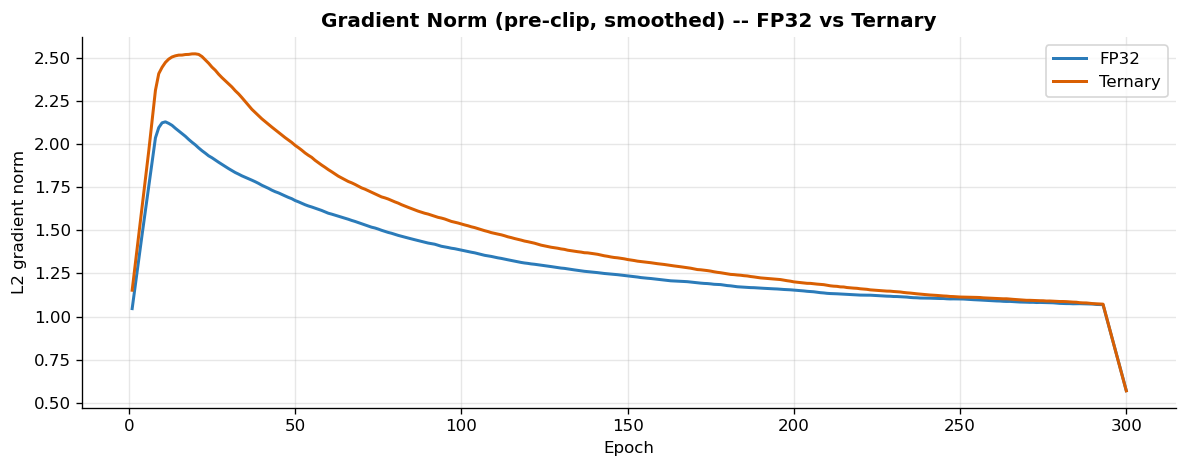

Metric                                          FP32     Ternary
-----------------------------------------------------------------
Mean grad norm (all epochs)                   1.3499      1.4900
Max  grad norm                                2.2359      2.6518
Grad norm std (volatility)                    0.2970      0.4317


In [11]:
# -----------------------------------------------------------------------
# Gradient norms reveal how much the straight-through estimator distorts
# the gradient signal relative to the FP32 model.
# Persistently higher norms in the ternary model indicate STE instability.
# -----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(epochs_range, smooth(fp32_m['grad_norm'],    15), color=COLOUR_FP32,    linewidth=1.8, label='FP32')
ax.plot(epochs_range, smooth(ternary_m['grad_norm'], 15), color=COLOUR_TERNARY, linewidth=1.8, label='Ternary')

ax.set_title('Gradient Norm (pre-clip, smoothed) -- FP32 vs Ternary', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('L2 gradient norm')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'gradient_norms.png', bbox_inches='tight')
plt.show()

print(f'{"Metric":<40}  {"FP32":>10}  {"Ternary":>10}')
print('-' * 65)
print(f'{"Mean grad norm (all epochs)":<40}  {np.mean(fp32_m["grad_norm"]):>10.4f}  {np.mean(ternary_m["grad_norm"]):>10.4f}')
print(f'{"Max  grad norm":<40}  {max(fp32_m["grad_norm"]):>10.4f}  {max(ternary_m["grad_norm"]):>10.4f}')
print(f'{"Grad norm std (volatility)":<40}  {np.std(fp32_m["grad_norm"]):>10.4f}  {np.std(ternary_m["grad_norm"]):>10.4f}')

### 4. Per-Task Accuracy

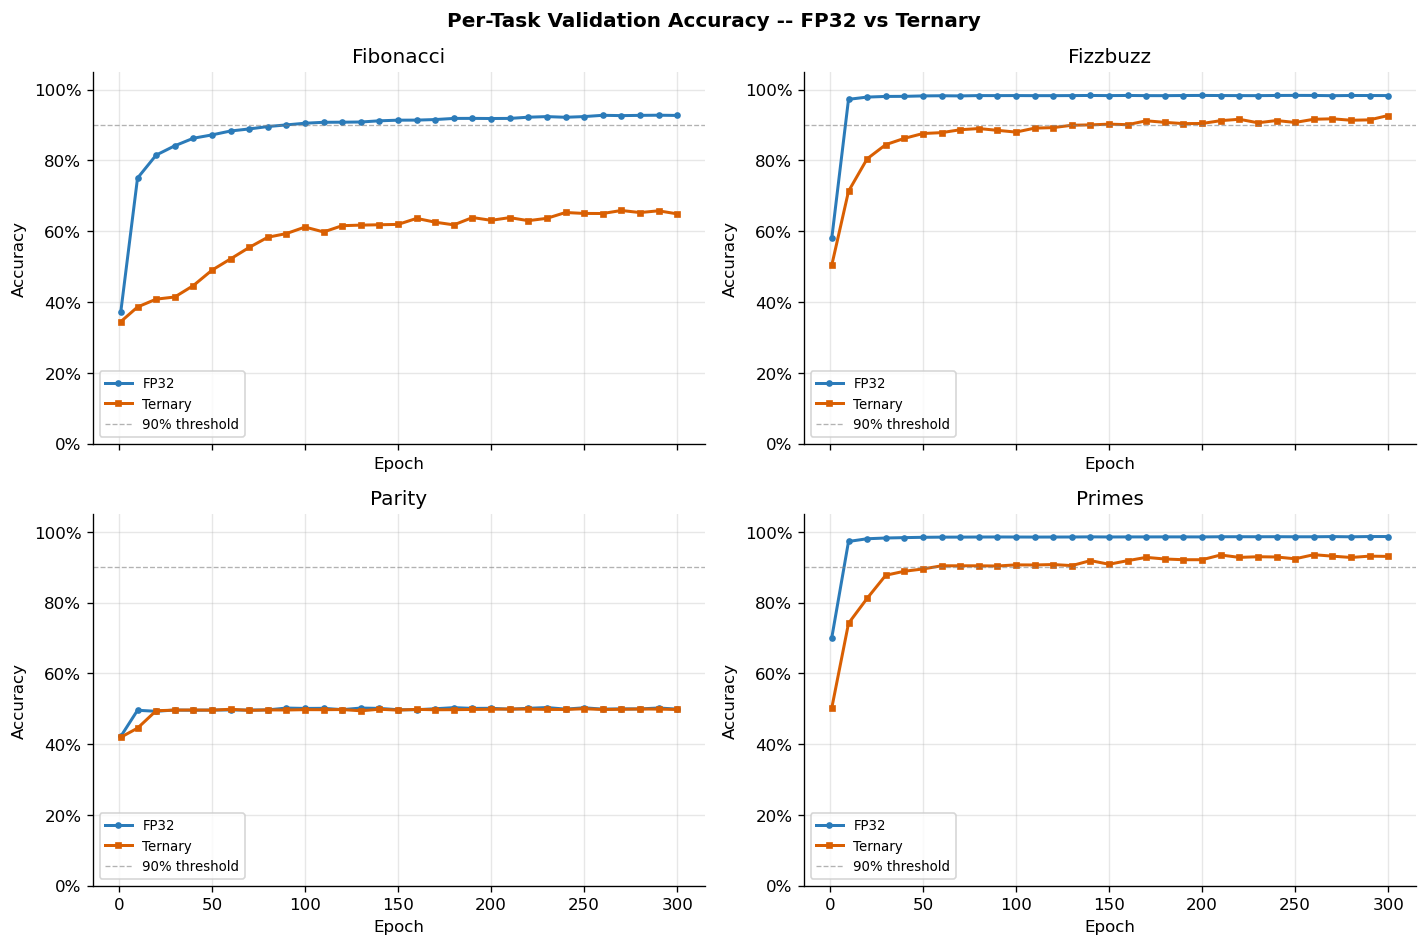

Task               FP32 final   Ternary final     Delta
-------------------------------------------------------
fibonacci              92.7%          64.9%    -27.8%
fizzbuzz               98.3%          92.7%     -5.6%
parity                 49.9%          49.8%     -0.1%
primes                 98.7%          93.0%     -5.6%


In [12]:
# -----------------------------------------------------------------------
# Per-task accuracy over the evaluation checkpoints.
# One subplot per task so the convergence trajectory is visible without
# lines overlapping across four different scales.
# -----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, TASK_NAMES):
    fp32_acc    = fp32_m['task_accuracy'][name]
    ternary_acc = ternary_m['task_accuracy'][name]

    ax.plot(task_acc_epochs, fp32_acc,    color=COLOUR_FP32,    linewidth=1.8, marker='o', markersize=3, label='FP32')
    ax.plot(task_acc_epochs, ternary_acc, color=COLOUR_TERNARY, linewidth=1.8, marker='s', markersize=3, label='Ternary')

    # Reference line at 90% accuracy for convergence threshold analysis
    ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='90% threshold')

    ax.set_title(name.capitalize())
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

fig.suptitle('Per-Task Validation Accuracy -- FP32 vs Ternary', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'per_task_accuracy.png', bbox_inches='tight')
plt.show()

# Final accuracy table
print(f'{"Task":<15}  {"FP32 final":>12}  {"Ternary final":>14}  {"Delta":>8}')
print('-' * 55)
for name in TASK_NAMES:
    f = fp32_m['task_accuracy'][name][-1]
    t = ternary_m['task_accuracy'][name][-1]
    print(f'{name:<15}  {f:>11.1%}  {t:>13.1%}  {t - f:>+8.1%}')

### 5. Ternary Weight Distribution

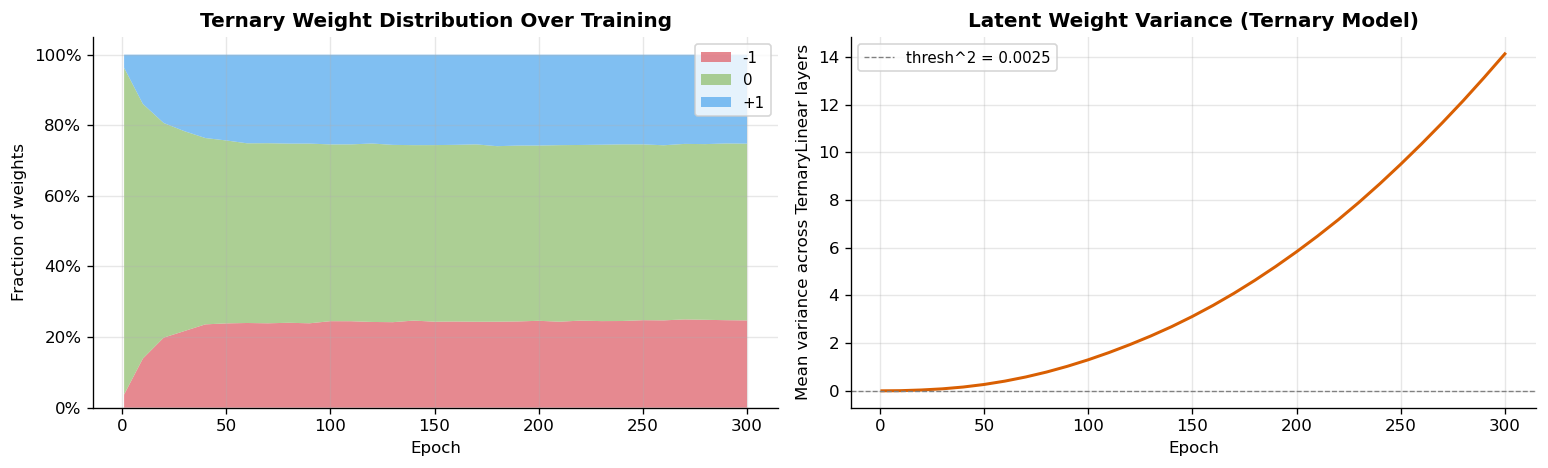

Final ternary weight distribution:
  -1 fraction : 0.247
   0 fraction : 0.501
  +1 fraction : 0.252
  Latent var  : 14.13797


In [13]:
# -----------------------------------------------------------------------
# Track how the fraction of weights at -1 / 0 / +1 evolves over training.
# Early training: most weights are near zero (high zero_frac).
# Later training: weights commit to -1 or +1 (zero_frac falls).
# A model where zero_frac never falls is functionally binary -- it never
# learned to use the zero value for selective suppression.
# -----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked area showing the three-way split over time
ax = axes[0]
neg1  = np.array(ternary_m['neg1_frac'])
zero  = np.array(ternary_m['zero_frac'])
pos1  = np.array(ternary_m['pos1_frac'])

ax.stackplot(
    ternary_epochs,
    neg1, zero, pos1,
    labels  = ['-1', '0', '+1'],
    colors  = ['#e06c75', '#98c379', '#61afef'],
    alpha   = 0.8,
)
ax.set_title('Ternary Weight Distribution Over Training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Fraction of weights')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper right', fontsize=9)

# Right: latent weight variance (indicator of how spread out the float
# values are -- high variance means weights are pushing hard against the
# threshold; low variance means they are clustered near zero)
ax = axes[1]
ax.plot(ternary_epochs, ternary_m['latent_var'], color=COLOUR_TERNARY, linewidth=1.8)
ax.axhline(TERNARY_THRESH ** 2, color='grey', linestyle='--', linewidth=0.8, label=f'thresh^2 = {TERNARY_THRESH**2:.4f}')
ax.set_title('Latent Weight Variance (Ternary Model)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean variance across TernaryLinear layers')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'ternary_weight_distribution.png', bbox_inches='tight')
plt.show()

print('Final ternary weight distribution:')
print(f'  -1 fraction : {neg1[-1]:.3f}')
print(f'   0 fraction : {zero[-1]:.3f}')
print(f'  +1 fraction : {pos1[-1]:.3f}')
print(f'  Latent var  : {ternary_m["latent_var"][-1]:.5f}')

### 6. Weight Churn Analysis

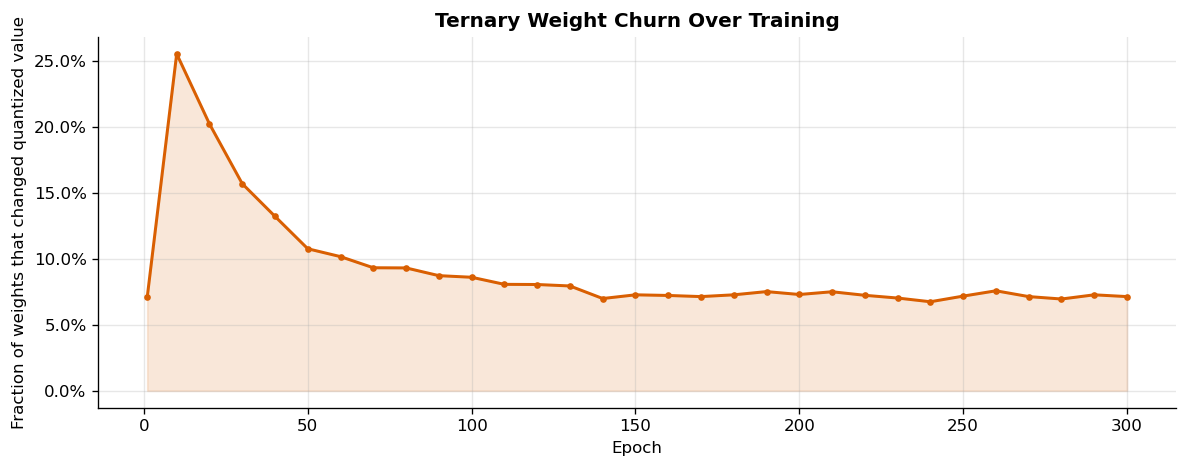

Peak churn epoch  : 10  (0.255)
Final churn       : 0.0714
Churn halving     : epoch where churn first dropped below 0.128
  -> epoch 1


In [ ]:
# -----------------------------------------------------------------------
# Weight churn is the fraction of ternary weights that changed their
# quantized value (e.g. 0 -> +1) between two consecutive evaluation
# checkpoints. It is a proxy for training stability:
#   High early churn  -- expected; model is still learning
#   Falling churn     -- weights are settling into stable ternary values
#   Near-zero churn   -- model has effectively converged
#   Persistent churn  -- STE instability, possibly needs LR adjustment
# -----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ternary_epochs, ternary_m['weight_churn'], color=COLOUR_TERNARY, linewidth=1.8, marker='o', markersize=3)
ax.fill_between(ternary_epochs, ternary_m['weight_churn'], alpha=0.15, color=COLOUR_TERNARY)

ax.set_title('Ternary Weight Churn Over Training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Fraction of weights that changed quantized value')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'weight_churn.png', bbox_inches='tight')
plt.show()

churn_arr   = np.array(ternary_m['weight_churn'])
peak_idx    = int(np.argmax(churn_arr))
peak_epoch  = ternary_epochs[peak_idx]
peak_churn  = churn_arr[peak_idx]
half_peak   = peak_churn / 2

print(f'Peak churn epoch  : {peak_epoch}  ({peak_churn:.3f})')
print(f'Final churn       : {churn_arr[-1]:.4f}')
print(f'Churn halving     : epoch where churn first dropped below {half_peak:.3f} after the peak')

# Search only after the peak to avoid pre-cascade values which are
# low by definition and would produce a misleading result
post_peak_churn  = churn_arr[peak_idx:]
post_peak_epochs = ternary_epochs[peak_idx:]
below = [e for c, e in zip(post_peak_churn, post_peak_epochs) if c < half_peak]
print(f'  -> epoch {below[0] if below else "not reached"}')

### 7. Convergence Analysis

In [15]:
# -----------------------------------------------------------------------
# Convergence speed: for each task, find the first evaluation epoch at
# which each model first exceeded 80% and 90% accuracy.
# A model that reaches 90% faster is more sample-efficient for that task.
# -----------------------------------------------------------------------

THRESHOLDS = [0.50, 0.80, 0.90]

print('Epoch at which each model first exceeded accuracy threshold:')
print()

for thresh in THRESHOLDS:
    print(f'Threshold : {thresh:.0%}')
    print(f'  {"Task":<15}  {"FP32 epoch":>12}  {"Ternary epoch":>14}')
    print('  ' + '-' * 45)

    for name in TASK_NAMES:
        fp32_epochs_above    = [e for e, a in zip(task_acc_epochs, fp32_m['task_accuracy'][name])    if a >= thresh]
        ternary_epochs_above = [e for e, a in zip(task_acc_epochs, ternary_m['task_accuracy'][name]) if a >= thresh]

        fp32_first    = fp32_epochs_above[0]    if fp32_epochs_above    else 'never'
        ternary_first = ternary_epochs_above[0] if ternary_epochs_above else 'never'

        print(f'  {name:<15}  {str(fp32_first):>12}  {str(ternary_first):>14}')

    print()

# -----------------------------------------------------------------------
# Epoch time comparison -- how much slower is ternary on CPU vs FP32?
# -----------------------------------------------------------------------

fp32_mean_time    = np.mean(fp32_m['epoch_time_s'])
ternary_mean_time = np.mean(ternary_m['epoch_time_s'])
total_fp32        = sum(fp32_m['epoch_time_s'])
total_ternary     = sum(ternary_m['epoch_time_s'])

print('Epoch timing (training only, CPU):')
print(f'  FP32    mean : {fp32_mean_time:.3f}s  |  total: {total_fp32 / 60:.1f} min')
print(f'  Ternary mean : {ternary_mean_time:.3f}s  |  total: {total_ternary / 60:.1f} min')
print(f'  Ratio        : {ternary_mean_time / fp32_mean_time:.2f}x  (>1 means ternary is slower during training)')
print()
print('Note: ternary is typically slower to TRAIN because STE overhead exceeds')
print('the saving from integer weights. The inference speed gain is separate')
print('and only materialises with purpose-built ternary kernels.')

Epoch at which each model first exceeded accuracy threshold:

Threshold : 50%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  10              60
  fizzbuzz                    1               1
  parity                     90           never
  primes                      1               1

Threshold : 80%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  20           never
  fizzbuzz                   10              20
  parity                  never           never
  primes                     10              20

Threshold : 90%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  90           never
  fizzbuzz                   10             140
  parity                  never           never
  primes                     10              60

Epoch timing (training 

### 8. Summary Table

In [17]:
# -----------------------------------------------------------------------
# Full comparison table -- one row per metric, FP32 and ternary columns.
# Delta column shows ternary - FP32 for numeric metrics so the sign
# makes the direction of difference immediately readable.
# -----------------------------------------------------------------------

SEP = '-' * 70

print(SEP)
print(f'{"METRIC":<38}  {"FP32":>10}  {"TERNARY":>10}  {"DELTA":>8}')
print(SEP)

def row(label, fp32_val, tern_val, fmt='.4f', delta=True):
    d = f'{tern_val - fp32_val:+.4f}' if delta else ''
    print(f'{label:<38}  {fp32_val:>10{fmt}}  {tern_val:>10{fmt}}  {d:>8}')


# Loss
row('Final train loss',      fp32_m['train_loss'][-1],  ternary_m['train_loss'][-1])
row('Final val loss',        fp32_m['val_loss'][-1],    ternary_m['val_loss'][-1])
row('Best val loss',         min(fp32_m['val_loss']),   min(ternary_m['val_loss']))

print()

# Gradient
row('Mean grad norm',        np.mean(fp32_m['grad_norm']),  np.mean(ternary_m['grad_norm']))
row('Grad norm std',         np.std(fp32_m['grad_norm']),   np.std(ternary_m['grad_norm']))

print()

# Per-task accuracy
for name in TASK_NAMES:
    row(
        f'Final accuracy -- {name}',
        fp32_m['task_accuracy'][name][-1],
        ternary_m['task_accuracy'][name][-1],
        fmt='.3f',
    )

print()

# Speed
row('Mean epoch time (s)',   fp32_mean_time, ternary_mean_time, fmt='.3f')
row('Total train time (s)',  total_fp32,     total_ternary,     fmt='.1f')

print()

# Ternary-only metrics (no FP32 equivalent)
print(f'{"TERNARY-ONLY METRICS":<38}')
print(SEP)
print(f'{"Final -1 weight fraction":<38}  {ternary_m["neg1_frac"][-1]:>10.3f}')
print(f'{"Final  0 weight fraction":<38}  {ternary_m["zero_frac"][-1]:>10.3f}')
print(f'{"Final +1 weight fraction":<38}  {ternary_m["pos1_frac"][-1]:>10.3f}')
print(f'{"Final weight churn":<38}  {ternary_m["weight_churn"][-1]:>10.4f}')
print(f'{"Final latent weight variance":<38}  {ternary_m["latent_var"][-1]:>10.5f}')

print(SEP)
print()
#  print(f'Plots saved to: {PLOT_DIR}')

----------------------------------------------------------------------
METRIC                                        FP32     TERNARY     DELTA
----------------------------------------------------------------------
Final train loss                            0.4402      0.7504   +0.3102
Final val loss                              0.2937      0.5706   +0.2769
Best val loss                               0.2924      0.5606   +0.2682

Mean grad norm                              1.3499      1.4900   +0.1401
Grad norm std                               0.2970      0.4317   +0.1347

Final accuracy -- fibonacci                  0.927       0.649   -0.2781
Final accuracy -- fizzbuzz                   0.983       0.927   -0.0563
Final accuracy -- parity                     0.499       0.498   -0.0009
Final accuracy -- primes                     0.987       0.930   -0.0561

Mean epoch time (s)                         37.765      37.798   +0.0330
Total train time (s)                       11329.4  